# Case Study 8: Heat Flow Meter Calibration

**Scenario:** A calibration experiment for a heat flow meter with two blocking factors: run (8 runs) and direction (2 directions — up/down). The response is a calibration factor. The goal is to estimate the calibration factor and assess whether run and direction have significant effects.

This is a two-factor balanced design. The block plot, ANOVA, and regression diagnostics all apply.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

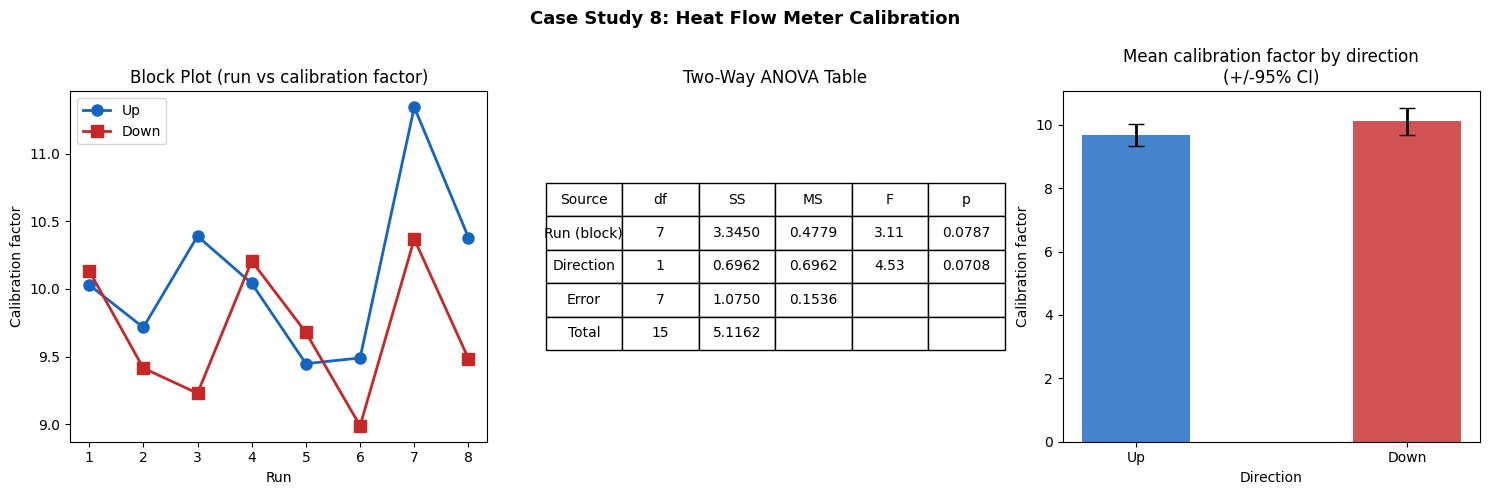

Grand mean calibration factor: 9.8967
Run (block) effect: F=3.112, p=0.0787 -> Not significant
Direction effect: F=4.533, p=0.0708 -> Not significant
  Up: mean=10.1053, std=0.6175
  Down: mean=9.6881, std=0.5001


In [2]:
np.random.seed(42)
n_runs = 8
directions = ['Up', 'Down']
run_effects = np.random.normal(0, 0.5, n_runs)
dir_effects = {'Up': 0.15, 'Down': -0.15}
grand_mean = 9.82

rows = []
for run in range(1, n_runs+1):
    for direction in directions:
        y = grand_mean + run_effects[run-1] + dir_effects[direction] + np.random.normal(0, 0.4)
        rows.append({'run': run, 'direction': direction, 'calibration': y})
df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Case Study 8: Heat Flow Meter Calibration', fontsize=13, fontweight='bold')

for direction, color, marker in zip(directions, ['#1565C0','#C62828'], ['o','s']):
    sub = df[df['direction']==direction].sort_values('run')
    axes[0].plot(sub['run'], sub['calibration'], marker=marker, color=color,
                 lw=2, ms=8, label=direction)
axes[0].set_title('Block Plot (run vs calibration factor)')
axes[0].set_xlabel('Run'); axes[0].set_ylabel('Calibration factor')
axes[0].set_xticks(range(1, n_runs+1)); axes[0].legend()

grand = df['calibration'].mean()
ss_run  = (df.groupby('run')['calibration'].mean() - grand).pow(2).sum() * 2
ss_dir  = (df.groupby('direction')['calibration'].mean() - grand).pow(2).sum() * n_runs
ss_tot  = ((df['calibration'] - grand)**2).sum()
ss_err  = ss_tot - ss_run - ss_dir
df_run  = n_runs - 1; df_dir = 1; df_err = (n_runs-1)*(2-1)
ms_run  = ss_run / df_run; ms_dir = ss_dir / df_dir; ms_err = ss_err / df_err
F_run   = ms_run / ms_err;  p_run  = stats.f.sf(F_run, df_run, df_err)
F_dir   = ms_dir / ms_err;  p_dir  = stats.f.sf(F_dir, df_dir, df_err)

table_data = [
    ['Run (block)', df_run, f'{ss_run:.4f}', f'{ms_run:.4f}', f'{F_run:.2f}', f'{p_run:.4f}'],
    ['Direction',   df_dir, f'{ss_dir:.4f}', f'{ms_dir:.4f}', f'{F_dir:.2f}', f'{p_dir:.4f}'],
    ['Error',       df_err, f'{ss_err:.4f}', f'{ms_err:.4f}', '',             ''],
    ['Total',       n_runs*2-1, f'{ss_tot:.4f}', '',          '',             ''],
]
axes[1].axis('off')
t = axes[1].table(cellText=table_data,
                   colLabels=['Source','df','SS','MS','F','p'],
                   loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1.1, 2.2)
axes[1].set_title('Two-Way ANOVA Table')

dir_means = df.groupby('direction')['calibration'].agg(['mean','std','count'])
axes[2].bar(directions, dir_means['mean'], color=['#1565C0','#C62828'], alpha=0.8, width=0.4)
axes[2].errorbar(directions, dir_means['mean'],
                 yerr=1.96*dir_means['std']/np.sqrt(dir_means['count']),
                 fmt='none', color='black', capsize=6, lw=2)
axes[2].set_title('Mean calibration factor by direction\n(+/-95% CI)')
axes[2].set_xlabel('Direction'); axes[2].set_ylabel('Calibration factor')

plt.tight_layout(); plt.show()

sig_run = 'Significant' if p_run < 0.05 else 'Not significant'
sig_dir = 'Significant' if p_dir < 0.05 else 'Not significant'
print(f'Grand mean calibration factor: {grand:.4f}')
print(f'Run (block) effect: F={F_run:.3f}, p={p_run:.4f} -> {sig_run}')
print(f'Direction effect: F={F_dir:.3f}, p={p_dir:.4f} -> {sig_dir}')
for d in directions:
    vals = df[df['direction']==d]['calibration']
    print(f'  {d}: mean={vals.mean():.4f}, std={vals.std(ddof=1):.4f}')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Run (block) effect** | Depends on data | Blocking captures run-to-run variation |
| **Direction effect** | Tested by F-test | Asymmetry in heat transfer up vs down |
| **Block plot** | Consistent ordering | Direction effect consistent across runs |
| **Model** | Two-way ANOVA | Calibration = grand mean + run + direction + error |

**Application:** The calibration factor adjusts heat flux measurements. Direction effect means separate calibration constants are needed for up-flow and down-flow configurations.